In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / 'Data').exists() and (ROOT_DIR / 'bcitoolbox_local').exists():
    ROOT_DIR = ROOT_DIR.parent

DATA_DIR = ROOT_DIR / 'Data'
if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))

from bcitoolbox_local import fit, simulateVV


In [6]:
MODEL = 'bci'
SIGMA_A = 0.2
MU_P = 1.5
FIX_SIGMA_P = False
FIXED_SIGMA_P = 1.5
LOCATION = 'visible'
N_SIMULATION = 1000
FIT_N_SIMULATION = 10000

GROUP_ORDER = ['Low Vision', 'Sighted Control']
GROUP_PALETTE = {
    'Low Vision': '#92b1d9',
    'Sighted Control': '#f4a261',
}
PLOT_PARAMS = ['pcommon', 'sigma_v', 'mu_p'] if FIX_SIGMA_P else ['pcommon', 'sigma_v', 'sigma_p', 'mu_p']
PARAM_TITLE = {
    'pcommon': r'$p_{common}$',
    'sigma_v': r'$\sigma_V$',
    'sigma_p': r'$\sigma_P$',
    'mu_p': r'$\mu_P$',
}

BEST_MODELS_PATH = DATA_DIR / 'csv/modeling/outputs/free_mup/sigma_a_p2/bci_best_models.csv'
MODELING_DATA_DIR = DATA_DIR / 'csv/modeling/data'
OUTPUT_PATH = DATA_DIR / 'csv/modeling/outputs/free_mup/sigma_a_p2/parameter_recovery_visible_bci_fixed_sp.csv' if FIX_SIGMA_P else DATA_DIR / 'csv/modeling/outputs/free_mup/sigma_a_p2/parameter_recovery_visible_bci.csv'
PLOT_PATH = ROOT_DIR / 'plots/figure_s5.png'

strategy_map = {
    'Averaging': 'ave',
    'Selection': 'sel',
    'Matching': 'mat',
}


def load_best_models():
    df = pd.read_csv(BEST_MODELS_PATH)
    df = df[df['location'] == LOCATION].copy()
    df['group'] = df['group'].replace({'Control': 'Sighted Control'})
    df = df[df['group'].isin(GROUP_ORDER)].copy()
    return df.sort_values(['group', 'subject_id']).reset_index(drop=True)


def build_synthetic_dataset(row, rng_seed=13):
    behavior_path = MODELING_DATA_DIR / f"{row['subject_id']}_{LOCATION}.csv"
    behavior_data = np.loadtxt(behavior_path, delimiter=',')

    true_sigma_p = FIXED_SIGMA_P if FIX_SIGMA_P else row['sigma_p']

    true_params = [
        row['pcommon'],
        row['sigma_v'],
        SIGMA_A,
        true_sigma_p,
        row['mu_p'],
    ]

    _, modelprop, _, _, _ = simulateVV(
        paras=true_params,
        n=N_SIMULATION,
        data=behavior_data,
        biOnly=0,
        strategy=strategy_map[row['strategy']],
        fitType=row['fit_type'],
    )

    stimuli = behavior_data[:, [0, 1]]
    conditions = np.unique(stimuli, axis=0)
    tiled_conditions = np.tile(conditions, (N_SIMULATION, 1))
    _, trial_type = np.unique(tiled_conditions, axis=0, return_inverse=True)

    rng = np.random.default_rng(rng_seed)
    synthetic = np.zeros((tiled_conditions.shape[0], 4))
    synthetic[:, :2] = tiled_conditions

    responses = np.zeros((tiled_conditions.shape[0], 2), dtype=int)
    for cond_idx in range(modelprop.shape[1]):
        idx = np.where(trial_type == cond_idx)[0]
        if idx.size == 0:
            continue

        for modality_idx in range(2):
            probabilities = modelprop[modality_idx, cond_idx, :].astype(float)
            probabilities = probabilities / (probabilities.sum() + 1e-12)
            responses[idx, modality_idx] = rng.choice(
                len(probabilities),
                size=idx.size,
                replace=True,
                p=probabilities,
            )

    synthetic[:, 2] = responses[:, 0]
    synthetic[:, 3] = responses[:, 1]
    return synthetic


def recover_parameters(row, synthetic_data):
    if FIX_SIGMA_P:
        n_parameters = 3
        bounds = [(0, 1), (0.1, 3), (0, 3.5)]
        es_para = [1, 1, 0, 0, 1, 0, 0]
        fixvalue = [0.5, 0.4, SIGMA_A, FIXED_SIGMA_P, MU_P, 0, 0]
    else:
        n_parameters = 4
        bounds = [(0, 1), (0.1, 3), (0.1, 3), (0, 3.5)]
        es_para = [1, 1, 0, 1, 1, 0, 0]
        fixvalue = [0.5, 0.4, SIGMA_A, 4000, MU_P, 0, 0]

    estimated, error, strategy_name, bic, r2, fixvalue = fit(
        n_parameters=n_parameters,
        n_Simulation=FIT_N_SIMULATION,
        Behavior_Data=synthetic_data,
        bounds=bounds,
        es_para=es_para,
        fixvalue=fixvalue,
        Strategies=[strategy_map[row['strategy']]],
        FitType=row['fit_type'],
    )

    true_sigma_p = FIXED_SIGMA_P if FIX_SIGMA_P else row['sigma_p']
    recovered_sigma_p = FIXED_SIGMA_P if FIX_SIGMA_P else estimated[2]

    return {
        'subject_id': row['subject_id'],
        'group': row['group'],
        'location': row['location'],
        'strategy': row['strategy'],
        'fit_type': row['fit_type'],
        'true_pcommon': row['pcommon'],
        'recovered_pcommon': estimated[0],
        'true_sigma_v': row['sigma_v'],
        'recovered_sigma_v': estimated[1],
        'sigma_a': SIGMA_A,
        'true_sigma_p': true_sigma_p,
        'recovered_sigma_p': recovered_sigma_p,
        'true_mu_p': row['mu_p'],
        'recovered_mu_p': estimated[3],
        # Backward-compatible alias for older saved recovery CSVs.
        'mu_p': estimated[3],
        'recovery_error': error,
        'recovery_bic': bic,
        'recovery_r2': r2,
        'recovered_strategy': strategy_name,
    }


best_models_df = load_best_models()
best_models_df[['subject_id', 'group', 'location', 'strategy', 'fit_type', 'pcommon', 'sigma_v', 'sigma_p']].head()

,subject_id,group,location,strategy,fit_type,pcommon,sigma_v,sigma_p
0,LV001,Low Vision,visible,Selection,mll,0.542465,0.394065,0.687814
1,LV002,Low Vision,visible,Selection,mll,0.521091,2.098361,2.291166
2,LV003,Low Vision,visible,Selection,mll,0.871774,1.012220,0.732343
3,LV005,Low Vision,visible,Selection,mll,0.526513,0.870617,0.751134
4,LV007,Low Vision,visible,Averaging,mll,0.649368,0.652536,0.716271


In [ ]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

records = []
for _, row in best_models_df.iterrows():
    print(f"Recovering {row['subject_id']} | {row['group']} | {row['location']}")
    synthetic_data = build_synthetic_dataset(row)
    records.append(recover_parameters(row, synthetic_data))

recovery_df = pd.DataFrame(records)
recovery_df.to_csv(OUTPUT_PATH, index=False)
recovery_df.head()


In [7]:
# Add true/recovered mu_p columns to the existing parameter recovery CSV without rerunning recovery.
recovery_df = pd.read_csv(OUTPUT_PATH)
true_mup_df = (
    best_models_df[['subject_id', 'location', 'mu_p']]
    .rename(columns={'mu_p': 'true_mu_p'})
)

recovery_df = recovery_df.drop(columns=['true_mu_p'], errors='ignore')
recovery_df = recovery_df.merge(true_mup_df, on=['subject_id', 'location'], how='left')

if 'recovered_mu_p' not in recovery_df.columns:
    recovery_df['recovered_mu_p'] = recovery_df['mu_p']

ordered_cols = []
for col in recovery_df.columns:
    if col == 'mu_p':
        ordered_cols.extend(['true_mu_p', 'recovered_mu_p', 'mu_p'])
    elif col not in ['true_mu_p', 'recovered_mu_p']:
        ordered_cols.append(col)
recovery_df = recovery_df[ordered_cols]

recovery_df.to_csv(OUTPUT_PATH, index=False)
recovery_df.head()

,subject_id,group,location,strategy,fit_type,true_pcommon,recovered_pcommon,true_sigma_v,recovered_sigma_v,sigma_a,true_sigma_p,recovered_sigma_p,true_mu_p,recovered_mu_p,mu_p,recovery_error,recovery_bic,recovery_r2,recovered_strategy
0,LV001,Low Vision,visible,Selection,mll,0.542465,0.522175,0.394065,0.402775,0.2,0.687814,0.751294,0.596841,0.529323,0.529323,841.330832,1715.837863,0.999858,Selection
1,LV002,Low Vision,visible,Selection,mll,0.521091,0.505735,2.098361,2.033515,0.2,2.291166,2.655500,1.008902,1.183992,1.183992,1029.386838,2091.949875,0.999663,Selection
2,LV003,Low Vision,visible,Selection,mll,0.871774,0.877088,1.012220,0.889390,0.2,0.732343,0.702237,1.359366,1.441729,1.441729,258.245793,549.667785,0.999977,Selection
3,LV005,Low Vision,visible,Selection,mll,0.526513,0.496628,0.870617,0.667507,0.2,0.751134,0.909219,0.510591,0.232248,0.232248,1166.686704,2366.549607,0.999660,Selection
4,LV007,Low Vision,visible,Averaging,mll,0.649368,0.623407,0.652536,0.542988,0.2,0.716271,0.763816,1.588864,1.896847,1.896847,595.444049,1224.064297,0.999973,Averaging


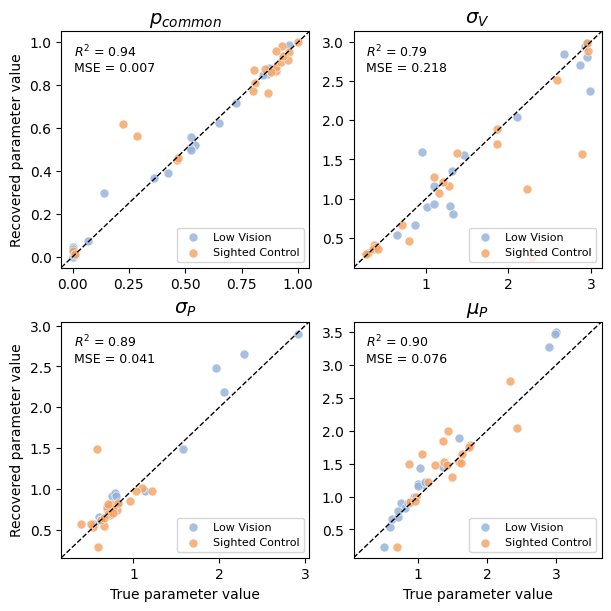

In [8]:
recovery_df = pd.read_csv(OUTPUT_PATH)


fig, axes = plt.subplots(2, 2, figsize=(6, 6), constrained_layout=True)
axes = axes.flatten()

for ax, param in zip(axes, PLOT_PARAMS):
    true_col = f'true_{param}'
    recovered_col = f'recovered_{param}'

    for group in GROUP_ORDER:
        group_df = recovery_df[recovery_df['group'] == group]
        ax.scatter(
            group_df[true_col],
            group_df[recovered_col],
            color=GROUP_PALETTE[group],
            alpha=0.8,
            s=42,
            edgecolors='white',
            linewidths=0.5,
            label=group,
        )

    all_df = recovery_df[[true_col, recovered_col]].dropna()
    lo = float(min(all_df[true_col].min(), all_df[recovered_col].min()))
    hi = float(max(all_df[true_col].max(), all_df[recovered_col].max()))
    span = hi - lo
    pad = 0.05 * span if span > 0 else 0.1
    lo -= pad
    hi += pad

    ax.plot([lo, hi], [lo, hi], linestyle='--', color='k', linewidth=1)

    x = all_df[true_col].to_numpy()
    y = all_df[recovered_col].to_numpy()
    r = pearsonr(x, y)[0]
    r2 = r ** 2
    mse = np.mean((x - y) ** 2)

    ax.text(
        0.05,
        0.95,
        f'$R^2$ = {r2:.2f}\nMSE = {mse:.3f}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
    )

    ax.set_title(PARAM_TITLE[param], fontsize=14)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.legend(loc='lower right', fontsize=8)

for x in [0, 2]:
    axes[x].set_ylabel('Recovered parameter value')
for x in [2, 3]:
    axes[x].set_xlabel('True parameter value')

# axes[1].legend(loc='lower right')

PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
plt.show()
